# Bias Analysis
###### Data Scientist: Maddalena Manfredi - 71946

This section performs a bias audit of the NovaCred credit-decision dataset to assess whether approval outcomes differ systematically across demographic groups. The goal is to identify potential patterns of discrimination and evaluate whether certain groups experience disproportionately lower approval rates.

To detect such disparities, the analysis applies commonly used algorithmic fairness metrics and statistical checks. A key metric used throughout the analysis is the Disparate Impact (DI) ratio, which compares the approval rate of an unprivileged group to that of a privileged group.
$$
DI = \frac{\text{approval rate (unprivileged group)}}{\text{approval rate (privileged group)}}
$$

A value of **_DI<0.8_** indicates potential disparate impact and therefore warrants further investigation

dopo aver individuato possibili disparità, andremo a testare tramite chi-square statistic test, se effettivamente c'è evidenza di una disparità o meno. poi per le varie variabili cerceremo di fare una interaction effect analysis e una proxy.

### Steps:
1. Loading 
2. DI analysis (gender/age/salary/geographic)
3. Interaction effect
4. Proxy
5. Conclusions and Reccomandations

In [18]:
##Libraries
import re, json
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import chi2_contingency
import seaborn as sns

## 1. Loading of the data

In [ ]:

# Load raw JSON
path = Path("..") / "Data" / "raw_credit_applications.json"
with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Flatten nested JSON → tabular
flat = pd.json_normalize(data, sep=".")

(502, 21)

In [5]:
flat.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


## 2. DI Analysis

## Gender Bias

We are gonna start our analysis on the first variable, the gender that is in the column named "applicant_info.gender".

 **Gender Data Cleaning**

The raw applicant_info.gender field contained multiple encodings: Male, Female, M, and F. To ensure consistency, we mapped M as Male and F as Female into a new "gender" variable. 


We have only 3 missing or invalid values that are gonna keepted in the dataset but excluded from binary fairness comparisons to avoid distorting the metrics.

In [7]:
# Gender encoding normalisation: M → Male, F → Female
gender_map = {"M": "Male", "F": "Female"}

flat["gender"] = (
    flat["applicant_info.gender"]
    .str.strip()
    .replace(gender_map)
    .where(lambda s: s.isin(["Male", "Female"]))  # set others (nulls, unknowns) to NaN
)

# Sanity check
print(flat["applicant_info.gender"].value_counts(dropna=False).rename("raw"))
print()
print(flat["gender"].value_counts(dropna=False).rename("clean"))

flat = flat.drop(columns=["applicant_info.gender"])

applicant_info.gender
Male      195
Female    193
F          58
M          53
            2
NaN         1
Name: raw, dtype: int64

gender
Female    251
Male      248
NaN         3
Name: clean, dtype: int64


gender
Female    0.505976
Male      0.657258

Absolute difference (Female - Male): -0.1513

Disparate Impact (Female / Male): 0.7698
→ POTENTIAL DISPARATE IMPACT (DI < 0.8)


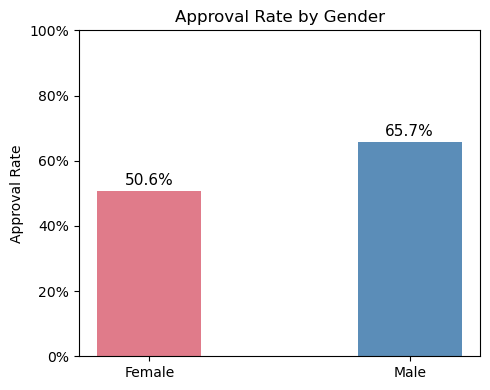

In [ ]:
# --- Disparate Impact: Gender ---

# Keep only records with known gender
df_gender = flat[flat["gender"].isin(["Male", "Female"])].copy()

# Approval rates per group
rates = (
    df_gender.groupby("gender")["decision.loan_approved"]
    .mean()
    .rename("approval_rate")
)
print(rates.to_string())

# Absolute difference
diff = abs(rates["Female"] - rates["Male"])
print(f"\nAbsolute difference (Female - Male): {rates['Female'] - rates['Male']:+.4f}")

# DI = approval_rate(Female) / approval_rate(Male)
DI_gender = rates["Female"] / rates["Male"]
print(f"\nDisparate Impact (Female / Male): {DI_gender:.4f}")
print("→", "POTENTIAL DISPARATE IMPACT (DI < 0.8)" if DI_gender < 0.8 else "No disparate impact detected (DI ≥ 0.8)")

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(rates.index, rates.values, color=["#E07B8A", "#5B8DB8"], width=0.4)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Approval Rate by Gender")
ax.set_ylabel("Approval Rate")
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**Interpretetaion:** The results indicate a disparity in approval rates between the two groups. Female applicants have an approval rate of approximately 0.51, while male applicants have an approval rate of approximately 0.66. The resulting **Disparate Impact (DI) ratio of 0.77** falls below the 0.8 threshold. This suggests the presence of a potential disparate impact against female applicants. 

#### Chi-square test of independence: gender vs loan approval

Approved  False  True 
gender                
Female      124    127
Male         85    163

Chi-square statistic : 11.1156
Degrees of freedom   : 1
p-value              : 0.0009
→ Statistically significant disparity (p < 0.05)


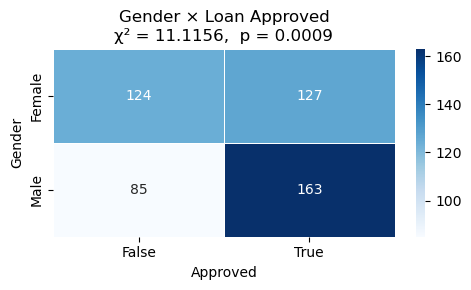

In [19]:
# Contingency table: gender × loan_approved
contingency = pd.crosstab(
    df_gender["gender"],
    df_gender["decision.loan_approved"],
    colnames=["Approved"]
)
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_value:.4f}")
print("→", "Statistically significant disparity (p < 0.05)" if p_value < 0.05 else "No statistically significant disparity (p ≥ 0.05)")


fig, ax = plt.subplots(figsize=(5, 3))

sns.heatmap(
    contingency,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Gender × Loan Approved\nχ² = {chi2:.4f},  p = {p_value:.4f}")
ax.set_xlabel("Approved")
ax.set_ylabel("Gender")

plt.tight_layout()
plt.show()



**Interpretetion:** The test produces a chi-square statistic of 11.12 and a p-value of 0.0009.
Since the p-value is below the significance level of 0.05, the null hypothesis of independence between gender and loan approval can be rejected. This indicates that **loan approval outcomes are statistically associated with gender**, consistent with the disparity suggested by the Disparate Impact metric.

### Interest Rate by Gender (approved only) 
We now investigate whether there is a difference in the interest rates offered to male and female.

          mean  median     std    n
gender                             
Female  4.4882     4.4  1.1929  127
Male    4.6282     4.7  1.1417  163

Mann-Whitney U statistic : 9655.0000
p-value                  : 0.3264
→ No significant difference in interest rates (p ≥ 0.05)


C:\Users\madda\AppData\Local\Temp\ipykernel_1440\905234345.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


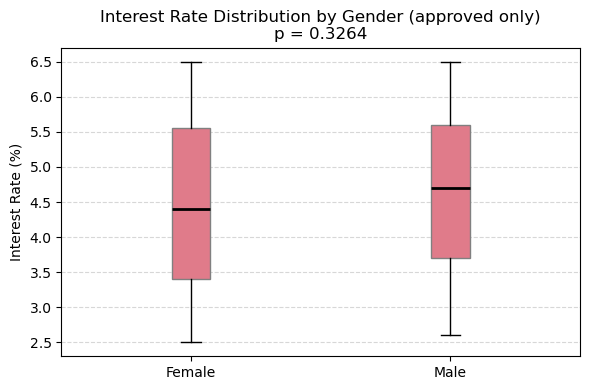

In [20]:
# --- Interest Rate by Gender (approved only) ---

df_approved = df_gender[df_gender["decision.loan_approved"] == True].copy()

ir_stats = (
    df_approved.groupby("gender")["decision.interest_rate"]
    .agg(mean="mean", median="median", std="std", n="count")
)
print(ir_stats.round(4))

# Mann-Whitney U test (non-parametric, no normality assumption)
from scipy.stats import mannwhitneyu

female_ir = df_approved[df_approved["gender"] == "Female"]["decision.interest_rate"].dropna()
male_ir   = df_approved[df_approved["gender"] == "Male"]["decision.interest_rate"].dropna()

stat, p_ir = mannwhitneyu(female_ir, male_ir, alternative="two-sided")
print(f"\nMann-Whitney U statistic : {stat:.4f}")
print(f"p-value                  : {p_ir:.4f}")
print("→", "Significant difference in interest rates (p < 0.05)" if p_ir < 0.05 else "No significant difference in interest rates (p ≥ 0.05)")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [female_ir, male_ir],
    labels=["Female", "Male"],
    patch_artist=True,
    boxprops=dict(facecolor="#E07B8A", color="gray"),
    medianprops=dict(color="black", linewidth=2)
)
ax.set_ylabel("Interest Rate (%)")
ax.set_title(f"Interest Rate Distribution by Gender (approved only)\np = {p_ir:.4f}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Interpretation:** The test produces a p-value of 0.3264, which is greater than the significance level of 0.05. Therefore, the null hypothesis cannot be rejected. This indicates that there is no statistically significant difference in the interest rates offered to male and female applicants among approved loans.

However, descriptively, female applicants appear to have a slightly lower average interest rate. This may be influenced by the presence of a subgroup of female borrowers who received particularly low interest rates (around 2.5%), which lowers the overall mean for women compared to men.

## Age Bias 

grazie alle analisi condotte nel file '01-data-quality', sappiamo che la variabile 'applicant_info.date_of_birth' ha un solo valore mancante, questo valore non sarà considerato durante l'analisi. Inoltre abbiamo fatto un pò di datacleaning per standardizzare la data di nascita, in quanto era scritta in maniera diversa con - e altre volte con /  , mentre la data alcune volte era AA/MM/GG altre GG/MM/AA ecc. dalla pulizzia è emerso che ci sono 4 righe in cui non è stato possibile identificare la data. 
Inoltre abbiamo 

In [34]:
# --- Date of Birth cleaning ---

def parse_dob(val):
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%Y/%m/%d"):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT

flat["clean_date_of_birth"] = flat["applicant_info.date_of_birth"].apply(parse_dob)

# Report
total     = len(flat)
null_orig = flat["applicant_info.date_of_birth"].isna().sum()
parsed    = flat["clean_date_of_birth"].notna().sum()
failed    = flat["clean_date_of_birth"].isna().sum() - null_orig

print(f"Total records        : {total}")
print(f"Originally null      : {null_orig}")
print(f"Successfully parsed  : {parsed}")
print(f"Still unparseable    : {failed}")
print(f"\nDate range: {flat['clean_date_of_birth'].min().date()} → {flat['clean_date_of_birth'].max().date()}")

reference_date = pd.Timestamp("2026-01-01")
flat["age"] = ((reference_date - flat["clean_date_of_birth"]) / pd.Timedelta(days=365.25)).astype("Int64")

print(flat[["_id", "clean_date_of_birth", "age"]].dropna().head(10))
print(f"\nAge range: {flat['age'].min()} → {flat['age'].max()}")



Total records        : 502
Originally null      : 1
Successfully parsed  : 497
Still unparseable    : 4

Date range: 1958-09-21 → 2002-04-24


TypeError: cannot safely cast non-equivalent object to int64

In [33]:
mask_failed = flat["clean_date_of_birth"].isna() & flat["applicant_info.date_of_birth"].notna()
print(flat.loc[mask_failed, ["_id", "applicant_info.date_of_birth"]])


         _id applicant_info.date_of_birth
26   app_075                             
275  app_120                             
448  app_350                             
462  app_165                             


In [21]:
# --- Age Distribution ---

# Compute age from date of birth
reference_date = pd.Timestamp("2024-01-01")  # anchor to dataset period
flat["age"] = ((reference_date - pd.to_datetime(flat["applicant_info.date_of_birth"])) / pd.Timedelta(days=365.25)).astype("Int64")

print(flat["age"].describe().round(1))

# Bin into age groups
bins   = [17, 25, 35, 45, 55, 65, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "65+"]
flat["age_group"] = pd.cut(flat["age"], bins=bins, labels=labels)

print("\nAge group counts:")
print(flat["age_group"].value_counts().sort_index())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of raw age
axes[0].hist(flat["age"].dropna(), bins=20, color="#5B8DB8", edgecolor="white")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution (raw)")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Right: count per age group
group_counts = flat["age_group"].value_counts().sort_index()
axes[1].bar(group_counts.index.astype(str), group_counts.values, color="#5B8DB8", edgecolor="white")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].set_title("Age Group Distribution")
for i, v in enumerate(group_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


ValueError: time data "14/02/1982" doesn't match format "%Y-%m-%d", at position 5. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

# 3. Interaction effect

voglio vedere se e come queste 3 variabili sono interdipendenti tra di loro

### Approvazione basata sull'età e il sesso
tra età e salary 
tra sesso e salary

4. heat map dove faccio vedere genere/età/ ID